## Google's page ranking mechanism

To make the simulation interesting, we do not use a toy irreversible ergodic Markov chain, instead we use one that is associated to how page ranking mechanism work. To explain it briefly, every node represent a website, and each transition represent the probability that a user goes from a starting website to the target website by clicking on a link present in the starting website. However, there is also some probability that the user opens a new tab and hence goes to a new website without clicking a link present in the starting website, to account for this, there is the so called damping factor $\alpha$. The page rank kernel is obtained as follow:

$\\ P = \alpha S + (1 - \alpha)\frac{1}{n}\mathbf{11^T} \\$

$S$ is the link following transition matrix obtained by a web bot that scrapes HTML files of a website and counts all the links.

$\alpha \in [0, 1]$ is the damping factor, i.e, the probability that the user do not open a new tab but follows a link inside the already opened tab.

$n$ is the number of nodes, i.e, websites.

$\mathbf{1}$ is the matrix where all entries are 1.

Also, in the literature, a node that represents a website with no links is called a dangling node.

We present therefore a full implementation, where the only inputs are the number of nodes, the damping factor, which by default is set to $0.85$ and the sparcity of the initial $S$. 


In [1]:
import numpy as np
import networkx as nx

def validate_power_of_two_dimension(dim):
    if not isinstance(dim, int):
        raise TypeError(f"dim must be an integer, got {type(dim)}.")

    if dim <= 0:
        raise ValueError(f"dim must be positive, got dim = {dim}.")

    if dim & (dim - 1) != 0:
        raise ValueError(
            f"dim must be a power of 2 for the current quantum implementation. "
            f"Got dim = {dim}."
        )

    return int(np.log2(dim))


def validate_markov_kernel(P, dim, tol=1e-12):
    P = np.asarray(P, dtype=float)

    if P.shape != (dim, dim):
        raise ValueError(
            f"P must have shape ({dim}, {dim}), but got shape {P.shape}."
        )

    if not np.all(np.isfinite(P)):
        raise ValueError("P contains NaN or infinite values.")

    if np.any(P < -tol):
        raise ValueError("P contains negative entries.")

    P = np.maximum(P, 0.0)

    row_sums = P.sum(axis=1)

    if not np.allclose(row_sums, np.ones(dim), atol=tol):
        raise ValueError(
            "Rows of P do not sum to 1. "
            f"Row sums are: {row_sums}"
        )

    P = P / P.sum(axis=1, keepdims=True)

    return P


dim = 8
alpha = 0.85

n_state_qubits = validate_power_of_two_dimension(dim)

if not (0 <= alpha <= 1):
    raise ValueError(f"alpha must be between 0 and 1, got alpha = {alpha}.")

G = nx.gnp_random_graph(
    n=dim,
    p=0.35,
    seed=7,
    directed=True
)

P = np.asarray(
    nx.google_matrix(
        G,
        alpha=alpha,
        nodelist=list(range(dim))
    ),
    dtype=float
)

P = validate_markov_kernel(P, dim)

dangling_nodes = [i for i in range(dim) if G.out_degree(i) == 0]

print(P)
print("Shape:", P.shape)
print("Rows sum to 1:", np.allclose(P.sum(axis=1), np.ones(dim)))
print("All entries positive:", np.all(P > 0))
print("Minimum transition probability:", P.min())
print("Number of state qubits:", n_state_qubits)
print("Dangling nodes:", dangling_nodes)
print("Number of dangling nodes:", len(dangling_nodes))
print("P passed all checks.")

[[0.01875    0.23125    0.23125    0.01875    0.23125    0.01875
  0.01875    0.23125   ]
 [0.01875    0.01875    0.30208333 0.01875    0.30208333 0.30208333
  0.01875    0.01875   ]
 [0.44375    0.44375    0.01875    0.01875    0.01875    0.01875
  0.01875    0.01875   ]
 [0.18875    0.01875    0.18875    0.01875    0.18875    0.18875
  0.18875    0.01875   ]
 [0.30208333 0.01875    0.01875    0.01875    0.01875    0.01875
  0.30208333 0.30208333]
 [0.30208333 0.01875    0.01875    0.30208333 0.01875    0.01875
  0.01875    0.30208333]
 [0.01875    0.01875    0.86875    0.01875    0.01875    0.01875
  0.01875    0.01875   ]
 [0.30208333 0.01875    0.30208333 0.01875    0.01875    0.30208333
  0.01875    0.01875   ]]
Shape: (8, 8)
Rows sum to 1: True
All entries positive: True
Minimum transition probability: 0.018750000000000003
Number of state qubits: 3
Dangling nodes: []
Number of dangling nodes: 0
P passed all checks.


## Non reversible markov chain

We make here a complete automated implementation of a generic non reversible ergodic Markov chain. The notebook only take as input the dimension, which must be a power of 2, and the kernel. It then computes the full quantum circtuit and make a simulation to calculate the total variational distance between the theoretical stationary distribution and the obtained stationary distribution from the circuit.

In [2]:
from numpy.polynomial import Chebyshev, Polynomial, chebyshev
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

from scipy.linalg import null_space, block_diag
from scipy.optimize import minimize
from scipy.signal import fftconvolve

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram
from qiskit.providers.fake_provider import GenericBackendV2

import numpy as np

dim = 8

P = np.array([
    [0.54989,     0.34993,     0.079984,    0.019996,    0.0000467782, 0.0000554812, 0.0000605858, 0.0000371548],
    [0.04999,     0.59988,     0.29994,     0.04999,     0.0000467782, 0.0000554812, 0.0000605858, 0.0000371548],
    [0.019996,    0.079984,    0.54989,     0.34993,     0.0000467782, 0.0000554812, 0.0000605858, 0.0000371548],
    [0.29994,     0.04999,     0.04999,     0.59988,     0.0000467782, 0.0000554812, 0.0000605858, 0.0000371548],
    [0.0001731153,0.0002175774,0.0001991756,0.0002101316,0.4996,      0.09992,     0.34972,     0.04996],
    [0.0001731153,0.0002175774,0.0001991756,0.0002101316,0.29976,     0.4996,      0.04996,     0.14988],
    [0.0001731153,0.0002175774,0.0001991756,0.0002101316,0.04996,     0.34972,     0.4996,      0.09992],
    [0.0001731153,0.0002175774,0.0001991756,0.0002101316,0.09992,     0.04996,     0.29976,     0.54956],
], dtype=float)

# Safety renormalization, because the numbers above are rounded
P = P / P.sum(axis=1, keepdims=True)
# Basis

eye = np.identity(dim)
basis = np.asarray([row.reshape(-1,1) for row in eye])

eigvals, eigvecs = np.linalg.eig(P.T)

# Finding the index of the eigenvalue equal to 1

index = np.where(np.isclose(eigvals, 1))[0][0]

# Retreiving the stationary distribution and normalizing it

pi = np.real(eigvecs[:, index])

if np.sum(pi) < 0:
    pi = -pi

pi = pi / np.sum(pi)

# defining pi state

pi_state = np.sqrt(pi).reshape(-1, 1)

print(f"Markov kernel loaded: \n{P}")

print(f"Stationary distribution: {pi}")
print(f"State of the stationary distribution: {pi_state}")

# Non reversability check

reversible = True

for i in range(P.shape[0]):
    for j in range(P.shape[0]):

        if not np.allclose(pi[i]*P[i, j],  pi[j]*P[j, i]):
            reversible = False
            break
    
    if not reversible:
        break

assert not reversible, "Chain is reversible"
print("The chain is not reversible")

# Computing the time reversal chain

P_rev = np.zeros((dim, dim))

for i in range(P.shape[0]):
    for j in range(P.shape[0]):

        P_rev[i][j] = (pi[j]/pi[i]) * P[j][i]

print(f"Time reversal chain: \n{P_rev}")

Markov kernel loaded: 
[[5.498900e-01 3.499300e-01 7.998400e-02 1.999600e-02 4.677820e-05
  5.548120e-05 6.058580e-05 3.715480e-05]
 [4.999000e-02 5.998800e-01 2.999400e-01 4.999000e-02 4.677820e-05
  5.548120e-05 6.058580e-05 3.715480e-05]
 [1.999600e-02 7.998400e-02 5.498900e-01 3.499300e-01 4.677820e-05
  5.548120e-05 6.058580e-05 3.715480e-05]
 [2.999400e-01 4.999000e-02 4.999000e-02 5.998800e-01 4.677820e-05
  5.548120e-05 6.058580e-05 3.715480e-05]
 [1.731153e-04 2.175774e-04 1.991756e-04 2.101316e-04 4.996000e-01
  9.992000e-02 3.497200e-01 4.996000e-02]
 [1.731153e-04 2.175774e-04 1.991756e-04 2.101316e-04 2.997600e-01
  4.996000e-01 4.996000e-02 1.498800e-01]
 [1.731153e-04 2.175774e-04 1.991756e-04 2.101316e-04 4.996000e-02
  3.497200e-01 4.996000e-01 9.992000e-02]
 [1.731153e-04 2.175774e-04 1.991756e-04 2.101316e-04 9.992000e-02
  4.996000e-02 2.997600e-01 5.495600e-01]]
Stationary distribution: [0.17311527 0.21757744 0.19917564 0.21013163 0.04677825 0.05548118
 0.06058578 

## Main operators

The goal is to implement the following circuit:

$\\ (\bra{01} \otimes \square_P^\dagger)G(\ket{01} \otimes \square_P) \\$
To do so, the first step is to define the following operators:
$\\
    \square_P = \sum_{x \in S}\ket{x}\ket{P(x, .)}\bra{x} \\
    \square_{P^*} = \sum_{x \in S}\ket{x}\ket{P^*(x, .)}\bra{x} \\
    S = \sum_{x, y \in S} \ket{x, y}\bra{y, x}
$

And $G$ is obtained via GQSP. This time the chebyschev polynomial is applied to a different walk operator which is:

$\\ W = (2\widehat{\square}\widehat{\square}^\dagger - I)\widehat{S} \\$

where

$\\ \widehat{\square} = (\ket{0}\bra{0} \otimes \square_{P^*} + \ket{1}\bra{1} \otimes \square_P) \\ 
\widehat{S} = (\ket{0}\bra{0} \otimes S + \ket{1}\bra{1} \otimes S^\dagger)(X \otimes I)$


In [3]:
# Defining the isometries

square = np.zeros((dim * dim, dim))
square_rev = np.zeros((dim * dim, dim)) # both have dim = 16 x 4

for x in range(dim):
    for y in range(dim):
        square += np.sqrt(P[x][y]) * np.kron(basis[x], basis[y]) @ basis[x].conj().T
        square_rev += np.sqrt(P_rev[x][y]) * np.kron(basis[x], basis[y]) @ basis[x].conj().T

# Defining the swap operator

swap = np.zeros(((dim * dim), (dim * dim))) # dim 16 x 16

for x in range(dim):
    for y in range(dim):
        swap += np.kron(basis[x], basis[y]) @ np.kron(basis[y].conj().T, basis[x].conj().T)

# Defining hermitized square

proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
proj_1 = np.array([[0, 0], [0, 1]], dtype=complex) # both have dim 2 x 2

square_herm = np.kron(proj_0, square_rev) + np.kron(proj_1, square) # dim 32 x 8

# Defining hermitized swap

X_gate = np.array([[0, 1], [1, 0]], dtype=complex) # dim 2 x 2

I_space = np.eye(dim * dim, dtype=complex) # dim 16 x 16

swap_herm = (np.kron(proj_0, swap) + np.kron(proj_1, swap))@(np.kron(X_gate, I_space)) # dim 32 x 32

# Defining the hermitized walk operator

I_space_large = np.eye(dim*dim*2) # 32 x 32

W_herm = (2*square_herm@square_herm.conj().T - I_space_large)@swap_herm # dim 32 x 32

print(f"Walk operator: {W_herm}")

# Sanity checks

assert np.allclose(W_herm @ W_herm.conj().T, np.eye(dim * dim * 2)), "Critical error, walk operator is not unitary"

print("Walk operator is unitary")

print(f"Number of non zero elements: {np.count_nonzero(W_herm)}")


Walk operator: [[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]
Walk operator is unitary
Number of non zero elements: 1024


## Curved discriminant

The curved discriminant is defined as: $D = \square_{P^*}^\dagger S \square_P \\$ where each element is:

$D(x, y) = \sqrt{P^*(x, y)P(y, x)}$

Thus, we define it in the two ways and then do a sanity check for their equivalence.


In [4]:
# Defining the curved discriminant as the SPUE

D = square_rev.conj().T @ swap @ square # dim 4 x 4

# Sanity check for the equivalence

D_check = np.zeros((dim, dim))

for x in range(dim):
    for y in range(dim):

        D_check[x][y] = np.sqrt(P_rev[x, y]*P[y, x])

assert np.allclose(D, D_check), "Critical error in the definition of the curved discriminant"

print("Curved discriminant correctly loaded")
print(D)



Curved discriminant correctly loaded
[[5.49890000e-01 5.60431297e-02 2.14483329e-02 3.30455059e-01
  8.99890637e-05 9.80032761e-05 1.02412534e-04 8.02001747e-05]
 [3.12134615e-01 5.99880000e-01 7.65269299e-02 4.91271886e-02
  1.00885516e-04 1.09870141e-04 1.14813300e-04 8.99113257e-05]
 [7.45680360e-02 3.13489656e-01 5.49890000e-01 5.13464876e-02
  9.65250422e-05 1.05121333e-04 1.09850839e-04 8.60251783e-05]
 [1.81495186e-02 5.08679648e-02 3.40685440e-01 5.99880000e-01
  9.91442723e-05 1.07973826e-04 1.12831668e-04 8.83594921e-05]
 [8.99889586e-05 1.00885435e-04 9.65249623e-05 9.91441844e-05
  4.99600000e-01 3.26455914e-01 5.68572446e-02 8.90508372e-02]
 [9.80033012e-05 1.09870208e-04 1.05121396e-04 1.07973884e-04
  9.17490476e-02 4.99600000e-01 3.65454226e-01 4.08843550e-02]
 [1.02412552e-04 1.14813361e-04 1.09850895e-04 1.12831719e-04
  3.07296130e-01 4.78090276e-02 4.99600000e-01 2.34744747e-01]
 [8.02001289e-05 8.99113067e-05 8.60251584e-05 8.83594664e-05
  5.60579031e-02 1.8315086

## Spectral gap of the curved discriminant

A property of the curved discriminant is that it has both left and right singular vectors associated with singular value $1$ that exactly coincide with the sought probability distribution $\ket{\pi}. \\$
Before defining the chebyshev polynomial a crucial point is to find the spectral gap of the curved discriminant. Remember that the spectral gap is defined as $\delta = 1 - \sigma_2(D)$  where $\sigma_2(D)$ is the second largest singular value of $D$. 

In [5]:
# SVD of D

left_sv, svalues, right_sv = np.linalg.svd(D)

spectral_gap = 1 - svalues[1]

assert np.isclose(svalues[0], 1), print("Error: leading sv of D is not 1!")
print(f"Leading singular value of the curved discriminant is {svalues[0]}")
print(f"Second largest singular value: {svalues[1]}")
print(f"Spectral gap (The higher the better!): {spectral_gap}")

# Checking that both first right and left singular vector coincide with the pi state

left_vector = left_sv[:, 0]

right_vector = right_sv[0, :].conj()

# Making them positive since the pi state is positive

if np.real(left_vector[0]) < 0:
    left_vector = -left_vector
if np.real(right_vector[0]) < 0:
    right_vector = -right_vector

assert np.allclose(left_vector, right_vector), "Error: right and left singular error are not equal"
print("Right and left singular vector are equal")

assert np.allclose(pi_state.flatten(), right_vector) and np.allclose(pi_state.flatten(), left_vector), "Error: right or left singular vector do not match pi state"
print("Right and left singular vector match pi state")



Leading singular value of the curved discriminant is 1.0000000000000002
Second largest singular value: 0.99900000009992
Spectral gap (The higher the better!): 0.0009999999000800397
Right and left singular vector are equal
Right and left singular vector match pi state


## Increasing the spectral gap



In [6]:
"""d
ef spectral_gap(matrix):
    Computes 1 - lambda_2 for a given matrix, 
    where lambda_2 is the second leading eigenvalue.
    # 1. Compute all eigenvalues
    eigenvalues = np.linalg.eigvals(matrix)
    
    # 2. Extract the real parts 
    # (np.linalg.eigvals sometimes leaves tiny +0j imaginary artifacts due to floating point precision)
    real_evals = np.real(eigenvalues)
    
    # 3. Sort the eigenvalues in descending order
    # np.sort defaults to ascending, so we use [::-1] to reverse it
    sorted_evals = np.sort(real_evals)[::-1]
    
    # 4. Extract lambda_2 (the second item in the zero-indexed array)
    # We add a quick safety check just in case the state space is trivially small
    if len(sorted_evals) >= 2:
        lambda_2 = sorted_evals[1]
    else:
        lambda_2 = 0.0
        
    # 5. Return the spectral gap
    return 1.0 - lambda_2
    """

'd\nef spectral_gap(matrix):\n    Computes 1 - lambda_2 for a given matrix, \n    where lambda_2 is the second leading eigenvalue.\n    # 1. Compute all eigenvalues\n    eigenvalues = np.linalg.eigvals(matrix)\n\n    # 2. Extract the real parts \n    # (np.linalg.eigvals sometimes leaves tiny +0j imaginary artifacts due to floating point precision)\n    real_evals = np.real(eigenvalues)\n\n    # 3. Sort the eigenvalues in descending order\n    # np.sort defaults to ascending, so we use [::-1] to reverse it\n    sorted_evals = np.sort(real_evals)[::-1]\n\n    # 4. Extract lambda_2 (the second item in the zero-indexed array)\n    # We add a quick safety check just in case the state space is trivially small\n    if len(sorted_evals) >= 2:\n        lambda_2 = sorted_evals[1]\n    else:\n        lambda_2 = 0.0\n\n    # 5. Return the spectral gap\n    return 1.0 - lambda_2\n    '

In [7]:
"""
import numpy as np

import matplotlib.pyplot as plt

def find_tau_rev(P, P_rev, gamma_func, max_k=50):
    
    Finds tau_rev that maximizes gamma(P^k * P_rev^k) / k.
    
    Parameters:
    P (np.ndarray): The transition matrix P
    P_rev (np.ndarray): The reversed transition matrix P* (P_rev)
    gamma_func (callable): A function that takes a matrix and returns a scalar gamma
    max_k (int): The maximum value of k to search through
    
    Returns:
    int: tau_rev (the k that maximizes the expression)
    np.ndarray: Array of evaluated k values
    np.ndarray: Array of the expression values for each k
    
    k_values = np.arange(1, max_k + 1)
    gamma_inf_values = []

    for k in k_values:
        # Compute P^k and P_rev^k
        P_k = np.linalg.matrix_power(P, k)
        P_rev_k = np.linalg.matrix_power(P_rev, k)
        
        # Multiply them: P^k * (P*)^k
        M = P_k @ P_rev_k
        
        # Evaluate the expression: gamma(M) / k
        val = gamma_func(M) / k
        gamma_inf_values.append(val)
        
    gamma_inf_values = np.array(gamma_inf_values)
    
    # Find tau_rev (the k corresponding to the maximum value)
    max_idx = np.argmax(gamma_inf_values)
    tau_rev = k_values[max_idx]
    
    return tau_rev, k_values, gamma_inf_values


tau_rev, ks, gamma_vals = find_tau_rev(P, P_rev, gamma_func=spectral_gap, max_k=1000)
max_gamma_val = gamma_vals[ks == tau_rev][0]

print(f"Found tau_rev: {tau_rev}")
print(f"Pseudo specral gap of the non reversible kernel P: {max_gamma_val:.6f}")

# 3. Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(ks, gamma_vals, marker='o', linestyle='-', alpha=0.7, label=r'$\frac{\gamma(P^k (P^\star)^k)}{k}$')

# Highlight the maximum value (tau_rev)
plt.plot(tau_rev, max_gamma_val, marker='*', markersize=15, color='red', 
         label=f'Max at $k = {tau_rev}$ ($\\tau_{{rev}}$)')
plt.axvline(x=tau_rev, color='red', linestyle='--', alpha=0.5)

plt.title(r'Finding $\tau_{rev}$ for $\gamma_\infty(P)$')
plt.xlabel('$k$')
plt.ylabel('Expression Value')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

# 4. Compute the final matrices raised to tau_rev
P_tau_rev = np.linalg.matrix_power(P, tau_rev)
P_rev_tau_rev = np.linalg.matrix_power(P_rev, tau_rev)

print(f"\nMatrix P^{tau_rev}:\n", P_tau_rev)
print(f"\nMatrix P_rev^{tau_rev}:\n", P_rev_tau_rev)
"""

<>:1: SyntaxWarning: invalid escape sequence '\g'
<>:1: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_17325/1650013535.py:1: SyntaxWarning: invalid escape sequence '\g'
  """


'\nimport numpy as np\n\nimport matplotlib.pyplot as plt\n\ndef find_tau_rev(P, P_rev, gamma_func, max_k=50):\n\n    Finds tau_rev that maximizes gamma(P^k * P_rev^k) / k.\n\n    Parameters:\n    P (np.ndarray): The transition matrix P\n    P_rev (np.ndarray): The reversed transition matrix P* (P_rev)\n    gamma_func (callable): A function that takes a matrix and returns a scalar gamma\n    max_k (int): The maximum value of k to search through\n\n    Returns:\n    int: tau_rev (the k that maximizes the expression)\n    np.ndarray: Array of evaluated k values\n    np.ndarray: Array of the expression values for each k\n\n    k_values = np.arange(1, max_k + 1)\n    gamma_inf_values = []\n\n    for k in k_values:\n        # Compute P^k and P_rev^k\n        P_k = np.linalg.matrix_power(P, k)\n        P_rev_k = np.linalg.matrix_power(P_rev, k)\n\n        # Multiply them: P^k * (P*)^k\n        M = P_k @ P_rev_k\n\n        # Evaluate the expression: gamma(M) / k\n        val = gamma_func(M) / 

## Chebyshev polynomial

We now define the polynomial that will be applied in GQSP to $W$. We set $\epsilon=0.01$. In order to find the degree of the chebyshev polynomial, we use the well known extremely useful formula: 
$ \\ d = \frac{\operatorname{arccosh}(\frac{1}{\epsilon})}{\operatorname{arccosh}(\frac{1}{1 - \delta})}$

In [8]:
epsilon = 0.001

d_raw = np.arccosh(1 / epsilon) / np.arccosh(1 / (1 - spectral_gap))
d = int(np.ceil(d_raw))

print(f"Raw degree {d_raw}")

# Since GQSVT applies an even polynomial, we need to make it even

if d % 2 != 0:
    d += 1

print(f"Degree of chebyshev polynomial is: {d}")
#d = 2
#print(f"Chebyshev degree changed to {d} for experiment")

Raw degree 169.89051540057218
Degree of chebyshev polynomial is: 170


It is now time to define the polynomial which will be applied by GQSP. We do the following design choice: $\nu(x) = \epsilon T_d(\alpha x)$.

To find $\alpha$ we set the following contraint: $\nu(1) = 1$ since for the algorithm to work it must output $1$ if the singular value is 1. This leads to $\alpha = \cosh(\frac{\operatorname{arccosh}{(\frac{1}{\epsilon})}}{d}). \\$ Also, the design guarantees that all other garbage singular values are bounded by $\epsilon$ because $\alpha x_{garbage} \leq 1$.

In [9]:
alpha = np.cosh(np.arccosh(1 / epsilon) / d) 

# New spectral gap
delta_d = 1 - 1 / alpha 

#assert delta_d <= spectral_gap + 1e-12, ("The chosen degree is not large enough: delta_d > spectral_gap.")

# Building the polynomial

x_poly = Polynomial([0.0, alpha]) # we build alpha * x
nu_power = epsilon * Chebyshev.basis(d)(x_poly) # epsilon * T_d(alpha * x)

# Convert to chebyshex basis
nu = nu_power.convert(kind=Chebyshev)

# Coefficients that nu and the signal polynomial share a1, ...
coef = nu.coef

print(coef)


[ 3.18865988e+43  0.00000000e+00  6.27448008e+43  0.00000000e+00
  5.97583974e+43  0.00000000e+00  5.50946273e+43  0.00000000e+00
  4.91723070e+43  0.00000000e+00  4.24862622e+43  0.00000000e+00
  3.55394939e+43  0.00000000e+00  2.87824746e+43  0.00000000e+00
  2.25693084e+43  0.00000000e+00  1.71355688e+43  0.00000000e+00
  1.25974273e+43  0.00000000e+00  8.96757889e+42  0.00000000e+00
  6.18126930e+42  0.00000000e+00  4.12552090e+42  0.00000000e+00
  2.66598149e+42  0.00000000e+00  1.66793507e+42  0.00000000e+00
  1.01017956e+42  0.00000000e+00  5.92183611e+41  0.00000000e+00
  3.35955005e+41  0.00000000e+00  1.84412311e+41  0.00000000e+00
  9.79241708e+40  0.00000000e+00  5.02898134e+40  0.00000000e+00
  2.49719819e+40  0.00000000e+00  1.19866409e+40  0.00000000e+00
  5.56032193e+39  0.00000000e+00  2.49198948e+39  0.00000000e+00
  1.07875436e+39  0.00000000e+00  4.50936963e+38  0.00000000e+00
  1.81975315e+38  0.00000000e+00  7.08755435e+37  0.00000000e+00
  2.66345470e+37  0.00000

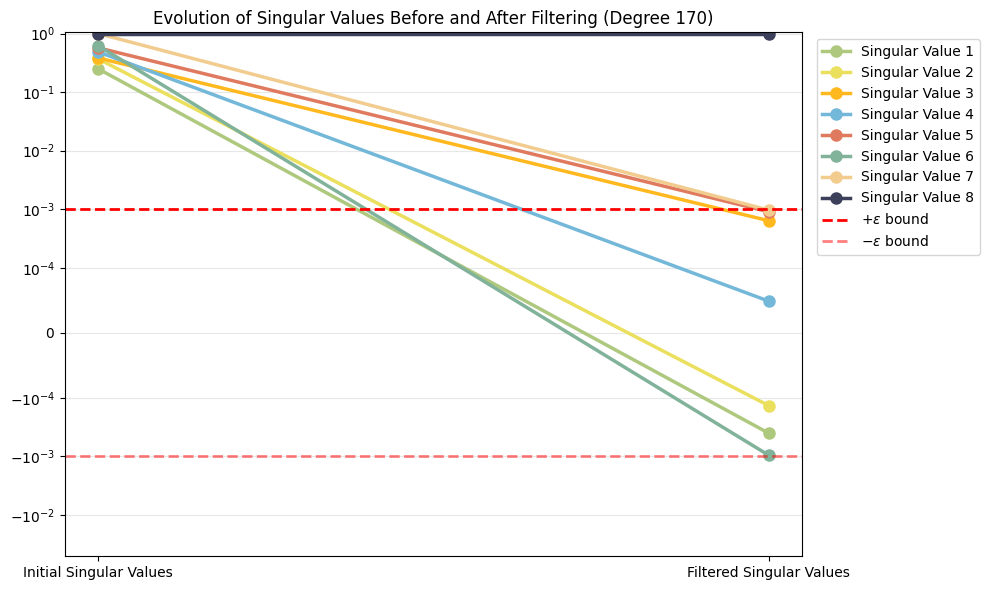

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Re-calculate Singular Values
dim = P.shape[0]
D_check = np.zeros((dim, dim))
for x in range(dim):
    for y in range(dim):
        D_check[x][y] = np.sqrt(P_rev[x, y] * P[y, x])

_, svalues, _ = np.linalg.svd(D_check)
sorted_evals = np.sort(svalues)

# 2. Re-calculate degree and alpha
epsilon = 0.001 
spectral_gap = 1.0 - sorted_evals[-2]

d_raw = np.arccosh(1 / epsilon) / np.arccosh(1 / (1 - spectral_gap))
d = int(np.ceil(d_raw))
if d % 2 != 0:
    d += 1 

alpha = np.cosh(np.arccosh(1 / epsilon) / d) 

# 3. DIRECT CHEBYSHEV EVALUATION
cheb_coeffs = [0.0] * d + [1.0]
filtered_evals = epsilon * np.polynomial.chebyshev.chebval(alpha * sorted_evals, cheb_coeffs)

# 4. Plotting
x_labels = ['Initial Singular Values', 'Filtered Singular Values']
colors = ['#aec97e', '#ebdf5e', '#ffb81d', '#73b7d9', 
          '#e07a5f', '#81b29a', '#f2cc8f', '#3d405b'] 

plt.figure(figsize=(10, 6))

for i in range(len(sorted_evals)):
    y_values = [sorted_evals[i], filtered_evals[i]]
    plt.plot(x_labels, y_values, marker='o', markersize=8, color=colors[i], 
             linewidth=2.5, label=f'Singular Value {i+1}')

# Epsilon bounds
plt.axhline(y=epsilon, color='red', linestyle='--', linewidth=2, label=r'$+\epsilon$ bound')
plt.axhline(y=-epsilon, color='red', linestyle='--', linewidth=2, alpha=0.5, label=r'$-\epsilon$ bound')

# THE MAGIC FIX: Symmetrical Log Scale
# linthresh tells matplotlib where to stop being logarithmic so it doesn't crash at zero
plt.yscale('symlog', linthresh=epsilon/10)

plt.title(f'Evolution of Singular Values Before and After Filtering (Degree {d})')
plt.grid(True, axis='y', alpha=0.3)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Quantum circuit

All the elements are now present to build the circuit. First we build the gates, some of which are not immediate and need unitary expansion, like the isometries.

In [11]:
# Function to build V_x such that it is unitary and its first column is |psi_x>
def complete_vector_to_unitary(v, atol=1e-12):
    """
    Given a normalized vector v in C^n, build a unitary U
    whose first column is v.
    """
    v = np.asarray(v, dtype=complex).reshape(-1, 1)
    n = v.shape[0]

    norm = np.linalg.norm(v)
    assert np.allclose(norm, 1.0, atol=atol), f"Input vector is not normalized. Norm = {norm}"

    # Find an orthonormal basis of the orthogonal complement of v.
    # This returns an n x (n-1) matrix Q such that v^dagger Q = 0.
    complement = null_space(v.conj().T)

    U = np.hstack([v, complement])

    assert np.allclose(U.conj().T @ U, np.eye(n), atol=atol), "Completion failed: U is not unitary."

    assert np.allclose(U[:, 0], v[:, 0], atol=atol), "First column is not the requested vector."

    return U


# Function to build V, controlled V_x
def build_controlled_unitary_extension(P, atol=1e-12):
    """
    Build V = sum_x |x><x| tensor V_x,
    where V_x |0> = sum_y sqrt(P[x,y]) |y>.
    """
    P = np.asarray(P, dtype=float)
    dim = P.shape[0]

    assert P.shape == (dim, dim), "P must be square."

    assert np.allclose(P.sum(axis=1), 1.0, atol=atol), "Rows of P must sum to 1."

    blocks = []

    for x in range(dim):
        psi_x = np.sqrt(P[x, :]).astype(complex)
        V_x = complete_vector_to_unitary(psi_x, atol=atol)
        blocks.append(V_x)

    V = block_diag(*blocks)

    assert np.allclose(V.conj().T @ V, np.eye(dim * dim), atol=atol), "V is not unitary."

    return V, blocks

In [12]:
V, V_Blocks = build_controlled_unitary_extension(P)

print(f"Shape of V: {V.shape}")
print(f"\nUnitary extension of square:\n{V}")

for x in range(dim):
    input_col = dim * x + 0
    assert np.allclose(V[:, input_col], square[:, x])

print("V correctly extends square.")

Shape of V: (64, 64)

Unitary extension of square:
[[ 0.74154568+0.j -0.59154881-0.j -0.28281443-0.j ...  0.        +0.j
   0.        +0.j  0.        +0.j]
 [ 0.59154881+0.j  0.7990693 -0.j -0.09606325-0.j ...  0.        +0.j
   0.        +0.j  0.        +0.j]
 [ 0.28281443+0.j -0.09606325-0.j  0.95407298-0.j ...  0.        +0.j
   0.        +0.j  0.        +0.j]
 ...
 [ 0.        +0.j  0.        +0.j  0.        +0.j ...  0.9506888 -0.j
  -0.12078727-0.j -0.16354674-0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j ... -0.12078727-0.j
   0.70413282-0.j -0.40060605-0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j ... -0.16354674-0.j
  -0.40060605-0.j  0.45757684-0.j]]
V correctly extends square.


In [13]:
# Ordering for qiskit
def math_to_qiskit_permutation_xy(dim):
    """
    Math order:    |x>|y>, index dim*x + y
    Qiskit order:  [qx0, qx1, qy0, qy1], index x + dim*y
    """
    N = dim * dim
    Perm = np.zeros((N, N), dtype=complex)

    for x_state in range(dim):
        for y_state in range(dim):
            math_index = dim * x_state + y_state
            qiskit_index = x_state + dim * y_state
            Perm[qiskit_index, math_index] = 1.0

    return Perm


def math_to_qiskit_permutation_hxy(dim):
    """
    Math order:    |h>|x>|y>, index h*dim*dim + dim*x + y
    Qiskit order:  [qx0, qx1, qy0, qy1, qh], index x + dim*y + dim*dim*h
    """
    N = 2 * dim * dim
    Perm = np.zeros((N, N), dtype=complex)

    for h_state in range(2):
        for x_state in range(dim):
            for y_state in range(dim):
                math_index = h_state * dim * dim + dim * x_state + y_state
                qiskit_index = x_state + dim * y_state + dim * dim * h_state
                Perm[qiskit_index, math_index] = 1.0

    return Perm

perm_xy = math_to_qiskit_permutation_xy(dim)
print(f"Permutation to go from big-endian to little-endian:\n{perm_xy.real}")
V_qiskit = perm_xy @ V @ perm_xy.conj().T

assert np.allclose(V_qiskit.conj().T @ V_qiskit, np.eye(dim*dim)), "V is not unitary."
print(f"\nV with little-endian ordering:\n{V_qiskit}")

Permutation to go from big-endian to little-endian:
[[1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]]

V with little-endian ordering:
[[0.74154568+0.j 0.        +0.j 0.        +0.j ... 0.        +0.j
  0.        +0.j 0.        +0.j]
 [0.        +0.j 0.22358444+0.j 0.        +0.j ... 0.        +0.j
  0.        +0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j 0.14140721+0.j ... 0.        +0.j
  0.        +0.j 0.        +0.j]
 ...
 [0.        +0.j 0.        +0.j 0.        +0.j ... 0.85206641+0.j
  0.        +0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j 0.        +0.j ... 0.        +0.j
  0.90137761+0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j 0.        +0.j ... 0.        +0.j
  0.        +0.j 0.45757684+0.j]]


We can now start the implementation, remember that we want to implement the following:

$(\bra{01} \otimes \square_P^\dagger) G (\ket{01} \otimes \square_P) = \ket{\pi}\bra{\pi}$

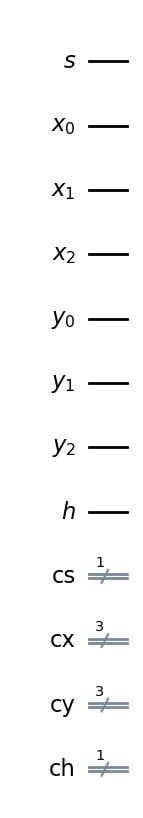

In [14]:
# Quantum registers, fully automated

assert 2**n_state_qubits== dim, "dimension of the kernel matrix must be a power of 2"

qs = QuantumRegister(1, "s") # Ancillary qubit for GQSP
qx = QuantumRegister(n_state_qubits, "x") # Register for the markov chain state
qy = QuantumRegister(n_state_qubits, "y") # Register for the markov chain target state
qh = QuantumRegister(1, "h") # New hermitianization qubit

# Classical registers

cs = ClassicalRegister(1, "cs")
cx = ClassicalRegister(n_state_qubits, "cx")
cy = ClassicalRegister(n_state_qubits, "cy")
ch = ClassicalRegister(1, "ch")

qc = QuantumCircuit(qs, qx, qy, qh, cs, cx, cy, ch)

qc.draw("mpl")

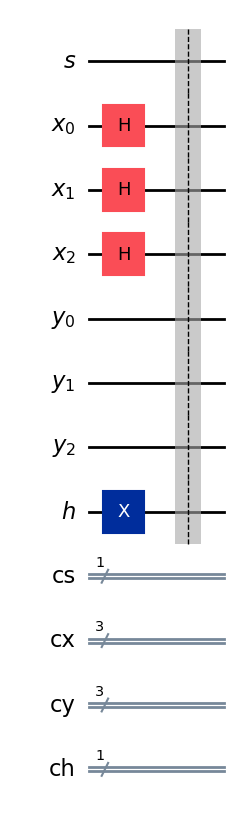

In [15]:
# Initialization

for q in qx:
    qc.h(q)

qc.x(qh[0])

qc.barrier()
qc.draw("mpl")

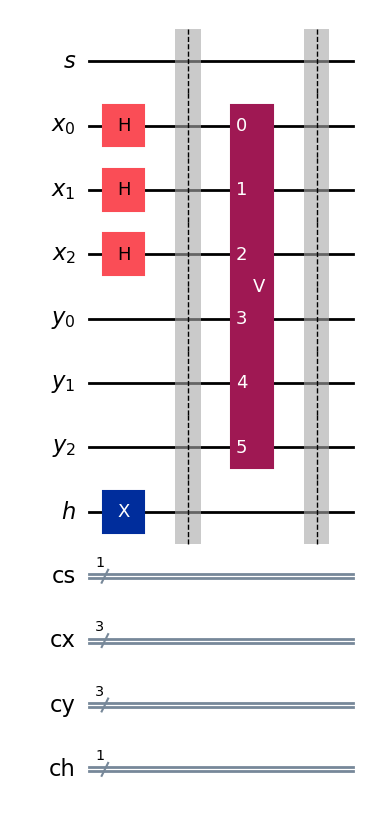

In [16]:
# Applying the first isometry

V_gate = UnitaryGate(V_qiskit, label="V")
qc.append(V_gate, list(qx) + list(qy))

qc.barrier()
qc.draw("mpl")

Here we apply the big gate, i.e, the GQSP, which this time will be applied on the hermitianized walk operator.

In [17]:
# Function simply implement the algorithm explained in the paper of GQSP
def find_Q_polynomial(P_coefs):
    """
    Calculates the coefficients of polynomial Q given polynomial P 
    for Generalized Quantum Signal Processing (GQSP).
    
    Args:
        P_coefs (numpy.ndarray): Complex coefficients of P [a_0, a_1, ..., a_d]
        
    Returns:
        numpy.ndarray: Complex coefficients of Q [b_0, b_1, ..., b_d]
    """
    a = np.array(P_coefs, dtype=complex)
    d = len(a) - 1
    
    a_rev_conj = np.conjugate(a[::-1])
    a_conv = fftconvolve(a, a_rev_conj)
    
    delta = np.zeros(2*d + 1, dtype=complex)
    delta[d] = 1.0
    
    target_b_conv = delta - a_conv
    
    def objective(b_concat):

        b = b_concat[:d+1] + 1j * b_concat[d+1:]
        
        # Compute b * reverse(b)*
        b_rev_conj = np.conjugate(b[::-1])
        b_conv = fftconvolve(b, b_rev_conj)
        
        # L2 norm squared of the difference
        diff = b_conv - target_b_conv
        return np.sum(np.abs(diff)**2)

    np.random.seed(42) # Fixed seed for reproducibility 
    b_init = np.random.randn(d+1) + 1j * np.random.randn(d+1)
    
    x0 = np.concatenate([np.real(b_init), np.imag(b_init)])
    
    result = minimize(objective, x0, method='L-BFGS-B', 
                      options={'maxiter': 50000, 'ftol': 1e-12})
    
    if not result.success:
        print(f"Warning: Optimization may not have fully converged. Message: {result.message}")
        print(f"Final objective value: {result.fun}")
        
    b_opt = result.x[:d+1] + 1j * result.x[d+1:]
    
    return b_opt

P_coefficients = np.array(coef)

Q_coefficients = find_Q_polynomial(P_coefficients)
print("Coefficients of P:")
print(np.round(P_coefficients, 4))
print("\nFound Coefficients for Q:")
print(np.round(Q_coefficients, 4))

Coefficients of P:
[ 3.18865988e+43  0.00000000e+00  6.27448008e+43  0.00000000e+00
  5.97583974e+43  0.00000000e+00  5.50946273e+43  0.00000000e+00
  4.91723070e+43  0.00000000e+00  4.24862622e+43  0.00000000e+00
  3.55394939e+43  0.00000000e+00  2.87824746e+43  0.00000000e+00
  2.25693084e+43  0.00000000e+00  1.71355688e+43  0.00000000e+00
  1.25974273e+43  0.00000000e+00  8.96757889e+42  0.00000000e+00
  6.18126930e+42  0.00000000e+00  4.12552090e+42  0.00000000e+00
  2.66598149e+42  0.00000000e+00  1.66793507e+42  0.00000000e+00
  1.01017956e+42  0.00000000e+00  5.92183611e+41  0.00000000e+00
  3.35955005e+41  0.00000000e+00  1.84412311e+41  0.00000000e+00
  9.79241708e+40  0.00000000e+00  5.02898134e+40  0.00000000e+00
  2.49719819e+40  0.00000000e+00  1.19866409e+40  0.00000000e+00
  5.56032193e+39  0.00000000e+00  2.49198948e+39  0.00000000e+00
  1.07875436e+39  0.00000000e+00  4.50936963e+38  0.00000000e+00
  1.81975315e+38  0.00000000e+00  7.08755435e+37  0.00000000e+00
  2.66

In [18]:
# This function computes the rotation angles given P and Q according to the algorithm given in the GQSP paper.
def compute_rotation_angles(S, d):
    """
    Computes the rotation angles for GQSP.
    
    Args:
        S (numpy.ndarray): 2 x (d+1) complex matrix where the first row 
                           contains the coefficients of P and the second row 
                           contains the coefficients of Q.
        d (int): Degree of the polynomials.
        
    Returns:
        tuple: (theta_list, phi_list, lambda_val)
               where theta_list and phi_list are ordered from index 0 to d.
    """
    theta_list = []
    phi_list = []
    
    # Make a copy to avoid mutating the original input
    current_S = np.array(S, dtype=complex)
    
    # Process from degree d down to 1
    for current_d in range(d, 0, -1):
        a_d = current_S[0][current_d]
        b_d = current_S[1][current_d]
        
        abs_a = np.abs(a_d)
        abs_b = np.abs(b_d)
        
        theta_d = np.arctan2(abs_b, abs_a)
        if abs_b == 0:
            phi_d = np.angle(a_d)
        elif abs_a == 0:
            phi_d = -np.angle(b_d)
        else:
            phi_d = np.angle(a_d * np.conj(b_d))
            
        theta_list.append(theta_d)
        phi_list.append(phi_d)
        
        exp_neg_i_phi = np.exp(-1j * phi_d)
        cos_t = np.cos(theta_d)
        sin_t = np.sin(theta_d)
        
        R_dagger = np.array([
            [exp_neg_i_phi * cos_t,  sin_t],
            [exp_neg_i_phi * sin_t, -cos_t]
        ])
        
        S_temp = R_dagger @ current_S
        
        P_hat = S_temp[0][1:]  
        
        Q_hat = S_temp[1][:-1] 
        
        current_S = np.array([P_hat, Q_hat])
        
    a_0 = current_S[0][0]
    b_0 = current_S[1][0]
    
    abs_a0 = np.abs(a_0)
    abs_b0 = np.abs(b_0)
    
    theta_0 = np.arctan2(abs_b0, abs_a0)
    
    if abs_b0 == 0:
        phi_0 = np.angle(a_0)
        lambda_val = 0.0
    elif abs_a0 == 0:
        phi_0 = -np.angle(b_0)
        lambda_val = np.angle(b_0)
    else:
        phi_0 = np.angle(a_0 * np.conj(b_0))
        lambda_val = np.angle(b_0)
        
    theta_list.append(theta_0)
    phi_list.append(phi_0)
    
    # Reverse the lists because we processed from d down to 0, 
    # but the circuit requires them from 0 up to d.
    theta_list.reverse()
    phi_list.reverse()
    
    return theta_list, phi_list, lambda_val

In [22]:
# Build S first

S = np.vstack([P_coefficients, Q_coefficients])

# Computing the angles
theta_list, phi_list, lambda_val = compute_rotation_angles(S, d)

print(f"Theta list: {theta_list}")
print(f"Phi list: {phi_list}")
print(f"lambda_val: {lambda_val}")

Theta list: [np.float64(0.5973775560356527), np.float64(0.26370657446194473), np.float64(1.0489778161517849), np.float64(0.29061376257644317), np.float64(0.6140110535913872), np.float64(0.3569583843726186), np.float64(0.29567496532970405), np.float64(0.7652501842703668), np.float64(0.19825823238995438), np.float64(1.0378828305174583), np.float64(0.6802436376395051), np.float64(0.358026973979982), np.float64(0.6295013163115569), np.float64(0.9254239566132755), np.float64(0.13269501171244352), np.float64(0.8564761751276802), np.float64(0.4912625330347131), np.float64(0.8512547102800562), np.float64(0.2984930583469684), np.float64(0.9761665715578405), np.float64(0.1777545600700994), np.float64(0.6448105913654731), np.float64(0.31550529583404796), np.float64(0.4843533641217939), np.float64(0.8514589795901192), np.float64(0.7252306806989655), np.float64(0.1966782345686392), np.float64(0.3824836313130847), np.float64(0.3374698532899593), np.float64(0.15426767136458797), np.float64(0.50232739

As the last notebook, we compute the rotation and controlled gate of GQSP.

In [23]:
# Defining the rotation gate, since it has parameters it needs to be 
# defined as a subclass of the Gate class

def RotationGate(theta, phi, lam):
    # Computes the GQSP rotation matrix and returns it as a Qiskit UnitaryGate 
    U = np.array([
        [
            np.exp(1j * (lam + phi)) * np.cos(theta),
            np.exp(1j * phi) * np.sin(theta)
        ],
        [
            np.exp(1j * lam) * np.sin(theta),
            -np.cos(theta)
        ]
    ], dtype=complex)
    
    # Wrap and return the matrix as a UnitaryGate
    return UnitaryGate(U, label=r"$R_{GQSP}$")

perm_hxy = math_to_qiskit_permutation_hxy(dim)
W_qiskit = perm_hxy @ W_herm @ perm_hxy.conj().T

assert np.allclose(W_qiskit.conj().T @ W_qiskit, np.eye(2 * dim * dim)), "W_qiskit not unitary"
        
# Defining the A gate
W_gate = UnitaryGate(W_qiskit, label="W")

A = W_gate.control(num_ctrl_qubits=1, ctrl_state="0")

Theta list: [np.float64(0.5973775560356527), np.float64(0.26370657446194473), np.float64(1.0489778161517849), np.float64(0.29061376257644317), np.float64(0.6140110535913872), np.float64(0.3569583843726186), np.float64(0.29567496532970405), np.float64(0.7652501842703668), np.float64(0.19825823238995438), np.float64(1.0378828305174583), np.float64(0.6802436376395051), np.float64(0.358026973979982), np.float64(0.6295013163115569), np.float64(0.9254239566132755), np.float64(0.13269501171244352), np.float64(0.8564761751276802), np.float64(0.4912625330347131), np.float64(0.8512547102800562), np.float64(0.2984930583469684), np.float64(0.9761665715578405), np.float64(0.1777545600700994), np.float64(0.6448105913654731), np.float64(0.31550529583404796), np.float64(0.4843533641217939), np.float64(0.8514589795901192), np.float64(0.7252306806989655), np.float64(0.1966782345686392), np.float64(0.3824836313130847), np.float64(0.3374698532899593), np.float64(0.15426767136458797), np.float64(0.50232739

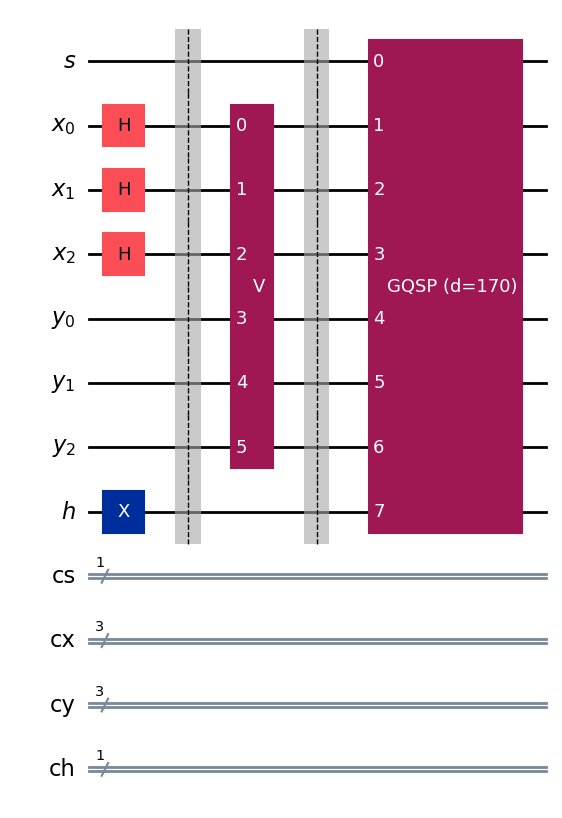

In [24]:
# 1. Initialize the empty sub-circuit (dynamically getting the degree from your lists)
d = len(theta_list) - 1
gqsp_qc = QuantumCircuit(qs, qx, qy, qh, name=f"GQSP (d={d})")

# 2. Run your loop, but apply everything to 'gqsp_qc' instead of 'qc'
for index, angle_theta in enumerate(theta_list):

    angle_phi = phi_list[index]

    if index == 0:
        R_gate = RotationGate(angle_theta, angle_phi, lambda_val)
    else:
        R_gate = RotationGate(angle_theta, angle_phi, 0)
        # CHANGED: append the Walk Operator A to the sub-circuit
        gqsp_qc.append(A, list(qs) + list(qx) + list(qy) + list(qh))

    # CHANGED: append the Rotation to the sub-circuit
    gqsp_qc.append(R_gate, qs)

# 3. Convert the entire 170-iteration sequence into a single custom block
gqsp_block = gqsp_qc.to_instruction()

# 4. Append the block to your main circuit 'qc'
qc.append(gqsp_block, list(qs) + list(qx) + list(qy) + list(qh))

# --- Prints and drawing remain exactly the same ---
print(f"Theta list: {theta_list}")
print(f"Phi list : {phi_list}")
print(f"Lambda: {lambda_val}")

qc.draw("mpl")


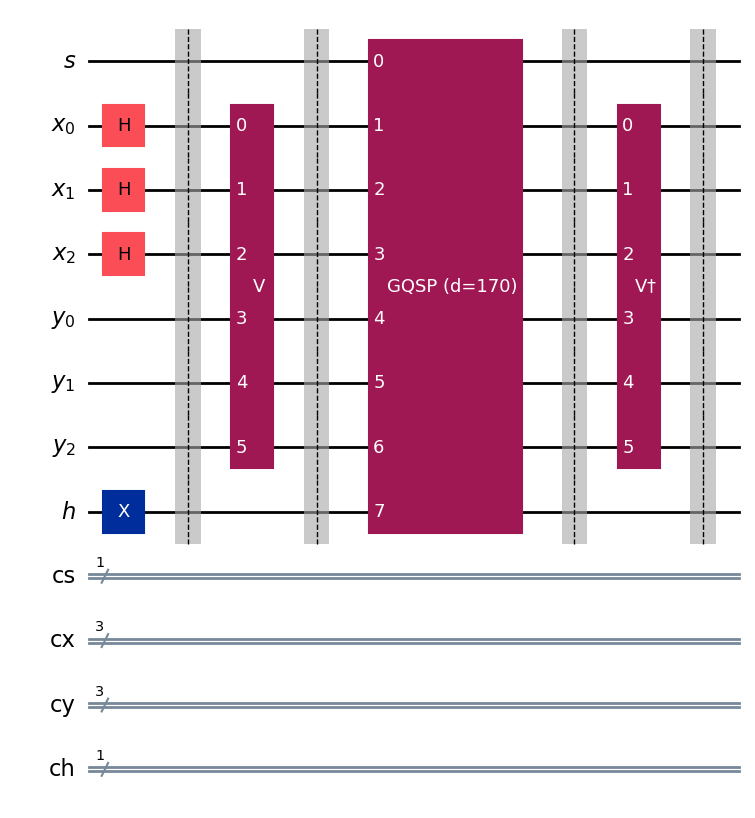

In [25]:
# Creating square dagger
qc.barrier()
V_gate_dagger = UnitaryGate(V_qiskit.conj().T, label=r"V$\dagger$")

qc.append(V_gate_dagger, list(qx) + list(qy))
qc.barrier()

qc.draw("mpl")

## Measurements

We now perform the measurements

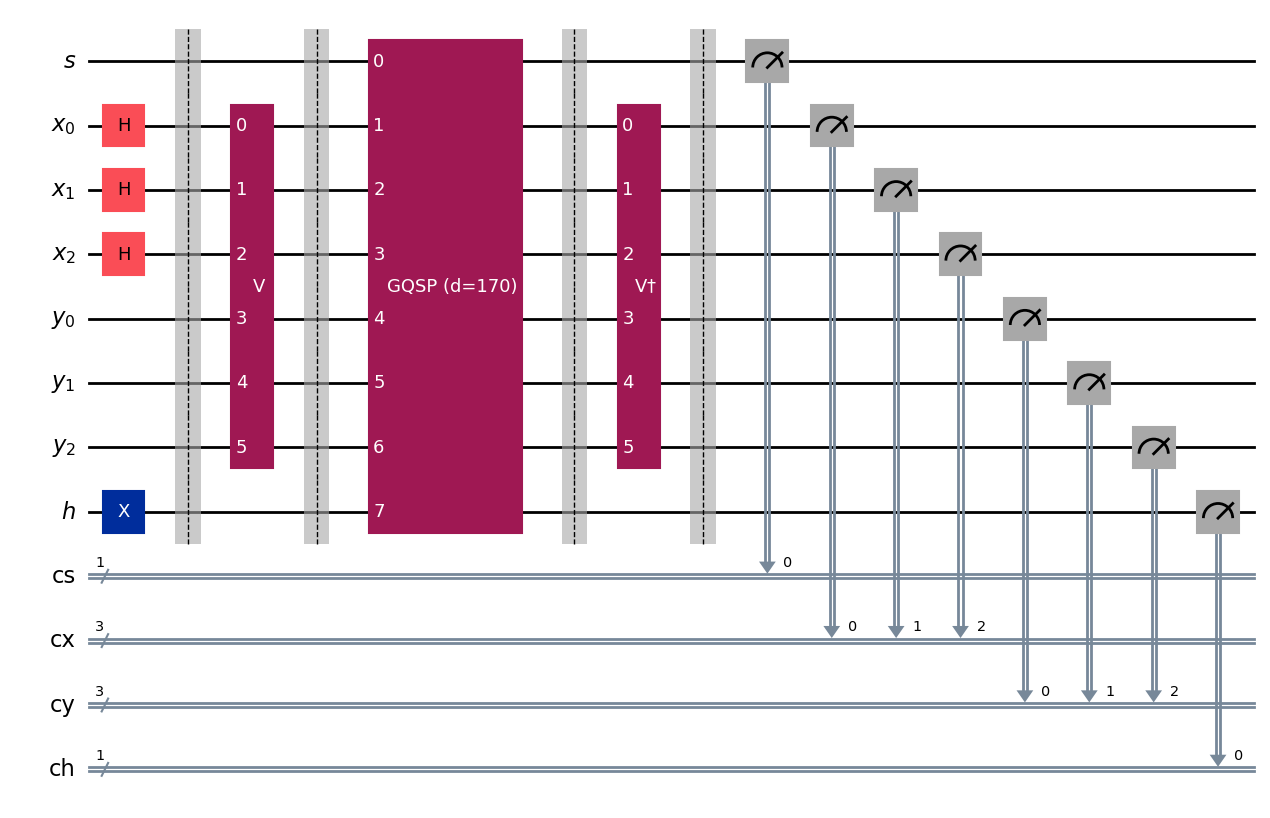

In [26]:
qc.measure(qs, cs)
qc.measure(qx, cx)
qc.measure(qy, cy)
qc.measure(qh, ch)

qc.draw("mpl")

## Simulation and results

Original circuit depth: 5
Compiled circuit depth: 5645206
Gate counts: OrderedDict({'cx': 2851586, 'u': 2782914, 'rz': 1576075, 'u2': 231880, 'unitary': 171, 'u3': 171, 'measure': 8, 'barrier': 4, 'h': 3, 'x': 1})
Raw counts: {'0 100 111 1': 1, '1 110 011 1': 3, '0 100 010 1': 5, '1 100 110 0': 5, '1 101 011 1': 3, '0 100 011 1': 12, '0 111 001 1': 8, '1 001 010 0': 6, '0 101 000 1': 8, '1 011 101 1': 2, '1 001 101 1': 2, '1 010 111 1': 3, '1 010 011 0': 6, '1 110 110 1': 2, '1 101 100 1': 1, '0 101 001 1': 4, '0 010 010 1': 4, '1 110 000 1': 4, '1 011 000 0': 4, '1 100 000 1': 2, '0 111 010 1': 6, '1 110 100 1': 3, '0 010 101 1': 6, '1 100 001 1': 3, '1 110 111 1': 1, '1 010 001 1': 3, '0 001 100 1': 6, '1 100 110 1': 7, '1 101 110 1': 3, '0 101 010 1': 11, '0 101 101 1': 7, '0 110 000 1': 6, '0 110 010 1': 11, '0 111 000 1': 7, '1 101 010 1': 2, '0 001 111 1': 7, '0 101 110 0': 60, '1 010 010 1': 3, '1 011 001 0': 7, '0 011 101 1': 9, '1 100 010 1': 3, '0 010 111 0': 221, '0 111 111 

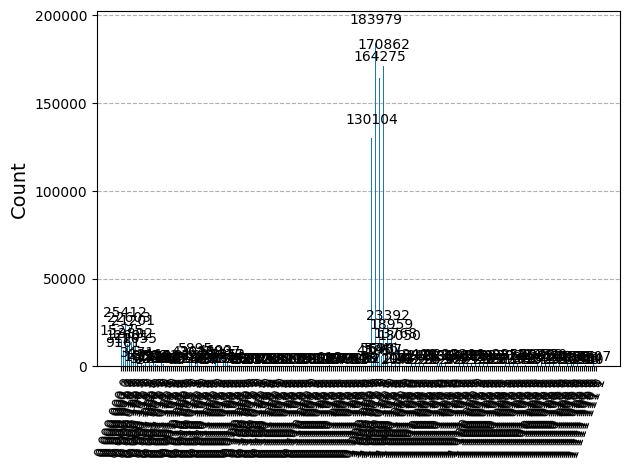

In [27]:
simulator_noiseless = AerSimulator() # Creating a virtual quantum computer

transpiled_qc = transpile(qc, simulator_noiseless) # Compiling the quantum circuit

print("Original circuit depth:", qc.depth())
print("Compiled circuit depth:", transpiled_qc.depth())
print("Gate counts:", transpiled_qc.count_ops())

# Running the circuit 1000 000 times
trials = 1000000
job = simulator_noiseless.run(transpiled_qc, shots=trials) # Running the simulation

results = job.result() # Obtaining the results from the simulation

raw_counts = results.get_counts()

print(f"Raw counts: {raw_counts}")
plot_histogram(raw_counts)

In [28]:
post_selected_counts = {}
successes = 0
zero_y = "0" * n_state_qubits 

for bitstring, count in raw_counts.items():
    # With registers (cs, cx, cy, ch), Qiskit usually prints groups
    # from last classical register to first:
    #     ch cy cx cs
    ch_val, cy_val, cx_val, cs_val = bitstring.split()

    # Correct post-selection:
    # s = 0  : GQSP signal ancilla success
    # h = 1  : bottom-right hermitianization block
    # y = all zero : projection back onto the isometry input subspace

    if cs_val == "0" and ch_val == "1" and cy_val == zero_y:
        post_selected_counts[cx_val] = post_selected_counts.get(cx_val, 0) + count
        successes += count

print(f"Post-selected counts: {post_selected_counts}")
print(f"Algorithm Success Rate: {(successes / trials) * 100:.2f}%\n")

probabilities = {
    bitstring: count / successes
    for bitstring, count in post_selected_counts.items()
}

print(f"Final probability distribution: {probabilities}\n")

# Convert Qiskit displayed bitstrings back to mathematical state indices.
# After the permutation fix, cx_bitstring already matches the mathematical state label.
measured = np.zeros(dim)

for cx_bitstring, prob in probabilities.items():
    i = int(cx_bitstring, 2)   # NO reverse
    measured[i] += prob

tvd = 0.5 * np.sum(np.abs(pi - measured))

print(f"Measured distribution ordered as states 0,1,2,3: {measured}")
print(f"Theoretical distribution: {pi}")
print(f"Total Variation Distance to theoretical distribution: {tvd:.4f}")

Post-selected counts: {'000': 130104, '110': 13768, '010': 164275, '101': 18959, '011': 170862, '001': 183979, '100': 23392, '111': 13050}
Algorithm Success Rate: 71.84%

Final probability distribution: {'000': 0.18110522293632, '110': 0.019165104142741606, '010': 0.22867137442249255, '101': 0.026390994294177666, '011': 0.23784050145533966, '001': 0.25609941132172126, '100': 0.032561745795105436, '111': 0.018165645632101827}

Measured distribution ordered as states 0,1,2,3: [0.18110522 0.25609941 0.22867137 0.2378405  0.03256175 0.02639099
 0.0191651  0.01816565]
Theoretical distribution: [0.17311527 0.21757744 0.19917564 0.21013163 0.04677825 0.05548118
 0.06058578 0.03715482]
Total Variation Distance to theoretical distribution: 0.1037


## Further analysis

First we check what is the number of steps needed classically to converge to a distribution that has the same total variational distance from the theoretical one that the quantum counterpart of degree 2. 

In [2]:
import numpy as np
def classic_evolution_from_state(degree, P, pi, start_state=0):
    dim = P.shape[0]

    dist = np.zeros(dim)
    dist[start_state] = 1.0

    for _ in range(degree):
        dist = dist @ P

    tvd = 0.5 * np.sum(np.abs(dist - pi))

    return dist, tvd


# Choose the target TVD you want to compare against
target_tvd = 0.1044

# Classical search range
max_classical_degree = 50000

classic_degrees = []
classic_tvds = []

dist = np.zeros(dim)
dist[0] = 1.0   # same start_state as classic_evolution

first_degree_below_target = None

for degree in range(max_classical_degree + 1):
    tvd = 0.5 * np.sum(np.abs(dist - pi))

    classic_degrees.append(degree)
    classic_tvds.append(tvd)

    if first_degree_below_target is None and tvd <= target_tvd:
        first_degree_below_target = degree
        break

    dist = dist @ P

print(f"Target TVD: {target_tvd}")

if first_degree_below_target is None:
    print(f"Classical chain did not reach TVD <= {target_tvd} by degree {max_classical_degree}.")
else:
    print(f"Classical chain reaches TVD <= {target_tvd} at degree {first_degree_below_target}.")
    print(f"Classical TVD at that degree: {classic_tvds[-1]:.6f}")

plt.figure(figsize=(10, 6))
plt.plot(classic_degrees, classic_tvds, marker="o", linewidth=2.5, label="Classical")
plt.axhline(target_tvd, linestyle="--", label=f"Target TVD = {target_tvd}")

if first_degree_below_target is not None:
    plt.axvline(first_degree_below_target, linestyle="--", label=f"Degree = {first_degree_below_target}")

plt.title("Classical Convergence to Stationarity")
plt.xlabel("Classical Markov Chain Steps")
plt.ylabel("Total Variation Distance")
plt.grid(True, alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'dim' is not defined

In [137]:
def run_nonreversible(P, dim, epsilon, simulator=AerSimulator(), degree=None):
    P = np.asarray(P, dtype=float)

    assert P.shape == (dim, dim), f"P has shape {P.shape}, expected ({dim}, {dim})"
    assert np.all(P >= -1e-12), "P has negative entries"
    assert np.allclose(P.sum(axis=1), np.ones(dim)), "Rows of P do not sum to 1"

    # Remove tiny numerical negatives and renormalize rows
    P = np.maximum(P, 0.0)
    P = P / P.sum(axis=1, keepdims=True)

    n_state_qubits = int(np.log2(dim))
    assert 2**n_state_qubits == dim, "dim must be a power of 2"

    eye = np.identity(dim)
    basis = np.asarray([row.reshape(-1, 1) for row in eye])

    # Compute stationary distribution INSIDE the function
    eigvals, eigvecs = np.linalg.eig(P.T)
    index = np.argmin(np.abs(eigvals - 1))

    pi = np.real(eigvecs[:, index])

    if np.sum(pi) < 0:
        pi = -pi

    pi = pi / np.sum(pi)

    # Numerical safety
    assert np.all(pi > -1e-10), "Stationary distribution has non-positive entries. Is P ergodic?"
    pi = np.maximum(pi, 0.0)
    pi = pi / np.sum(pi)

    pi_state = np.sqrt(pi).reshape(-1, 1)

    # Check non-reversibility
    reversible = True
    max_db_violation = 0.0

    for i in range(dim):
        for j in range(dim):
            violation = abs(pi[i] * P[i, j] - pi[j] * P[j, i])
            max_db_violation = max(max_db_violation, violation)

            if violation > 1e-10:
                reversible = False

    assert not reversible, "Chain is reversible"

    print("Stationary distribution pi:")
    print(pi)
    print("Maximum detailed-balance violation:", max_db_violation)

    # Compute time reversal chain
    P_rev = np.zeros((dim, dim))

    for i in range(dim):
        for j in range(dim):
            P_rev[i, j] = (pi[j] / pi[i]) * P[j, i]

    # Security checks on P_rev
    assert np.all(P_rev >= -1e-10), "P_rev has negative entries"
    P_rev = np.maximum(P_rev, 0.0)
    assert np.allclose(P_rev.sum(axis=1), np.ones(dim)), (
        "P_rev is not row-stochastic. "
        f"Row sums: {P_rev.sum(axis=1)}"
    )

    # Defining the isometries
    square = np.zeros((dim * dim, dim))
    square_rev = np.zeros((dim * dim, dim))

    for x in range(dim):
        for y in range(dim):
            square += np.sqrt(P[x][y]) * np.kron(basis[x], basis[y]) @ basis[x].conj().T
            square_rev += np.sqrt(P_rev[x][y]) * np.kron(basis[x], basis[y]) @ basis[x].conj().T

    # Defining the swap operator
    swap = np.zeros(((dim * dim), (dim * dim))) 
    for x in range(dim):
        for y in range(dim):
            swap += np.kron(basis[x], basis[y]) @ np.kron(basis[y].conj().T, basis[x].conj().T)
        
    # Defining hermitized square
    proj_0 = np.array([[1, 0], [0, 0]], dtype=complex)
    proj_1 = np.array([[0, 0], [0, 1]], dtype=complex)
    square_herm = np.kron(proj_0, square_rev) + np.kron(proj_1, square)

    # Defining hermitized swap
    X_gate = np.array([[0, 1], [1, 0]], dtype=complex)
    I_space = np.eye(dim * dim, dtype=complex)
    swap_herm = (np.kron(proj_0, swap) + np.kron(proj_1, swap))@(np.kron(X_gate, I_space))

    # Defining the hermitized walk operator
    I_space_large = np.eye(dim*dim*2)
    W_herm = (2*square_herm@square_herm.conj().T - I_space_large)@swap_herm
    assert np.allclose(W_herm @ W_herm.conj().T, np.eye(dim * dim * 2)), "Critical error, walk operator is not unitary"
    perm_hxy = math_to_qiskit_permutation_hxy(dim)
    W_qiskit = perm_hxy @ W_herm @ perm_hxy.conj().T
    assert np.allclose(W_qiskit.conj().T @ W_qiskit, np.eye(2 * dim * dim)), "W_qiskit not unitary"


    # Defining the curved discriminant
    D = square_rev.conj().T @ swap @ square # dim 4 x 4
    D_check = np.zeros((dim, dim))

    for x in range(dim):
        for y in range(dim):
            D_check[x][y] = np.sqrt(P_rev[x, y]*P[y, x])

    assert np.allclose(D, D_check), "Critical error in the definition of the curved discriminant"

    # Checks on D
    left_sv, svalues, right_sv = np.linalg.svd(D)
    spectral_gap = 1 - svalues[1]
    assert np.isclose(svalues[0], 1), print("Error: leading sv of D is not 1!")

    left_vector = left_sv[:, 0]
    right_vector = right_sv[0, :].conj()

    if np.real(left_vector[0]) < 0:
        left_vector = -left_vector
    if np.real(right_vector[0]) < 0:
        right_vector = -right_vector

    assert np.allclose(left_vector, right_vector), "Error: right and left singular error are not equal"
    assert np.allclose(pi_state.flatten(), right_vector) and np.allclose(pi_state.flatten(), left_vector), "Error: right or left singular vector do not match pi state"

    # Chebyshev polynomial
    if degree is None:
        d_raw = np.arccosh(1 / epsilon) / np.arccosh(1 / (1 - spectral_gap))
        d = int(np.ceil(d_raw))
        if d % 2 != 0:
            d += 1
    else:
        d = degree
    
    alpha = np.cosh(np.arccosh(1 / epsilon) / d) 
    x_poly = Polynomial([0.0, alpha])
    nu_power = epsilon * Chebyshev.basis(d)(x_poly)
    nu = nu_power.convert(kind=Chebyshev)
    coef = nu.coef
    P_coefficients = np.array(coef)
    Q_coefficients = find_Q_polynomial(P_coefficients)
    S = np.vstack([P_coefficients, Q_coefficients])
    theta_list, phi_list, lambda_val = compute_rotation_angles(S, d)

    # Build V unitary extansion of square
    V, V_Blocks = build_controlled_unitary_extension(P)
    perm_xy = math_to_qiskit_permutation_xy(dim)
    V_qiskit = perm_xy @ V @ perm_xy.conj().T
    assert np.allclose(V_qiskit.conj().T @ V_qiskit, np.eye(V_qiskit.shape[-1])), "V_qiskit not unitary"


    # Quantum circuit
    # Registers
    assert 2**n_state_qubits== dim, "dimension of the kernel matrix must be a power of 2"

    qs = QuantumRegister(1, "s")
    qx = QuantumRegister(n_state_qubits, "x")
    qy = QuantumRegister(n_state_qubits, "y")
    qh = QuantumRegister(1, "h")

    cs = ClassicalRegister(1, "cs")
    cx = ClassicalRegister(n_state_qubits, "cx")
    cy = ClassicalRegister(n_state_qubits, "cy")
    ch = ClassicalRegister(1, "ch")

    qc = QuantumCircuit(qs, qx, qy, qh, cs, cx, cy, ch)
    
    # Initialization
    for q in qx:
        qc.h(q)

    qc.x(qh[0])

    # V gate
    V_gate = UnitaryGate(V_qiskit, label="V")
    qc.append(V_gate, list(qx) + list(qy))

    # A gate
    W_gate = UnitaryGate(W_qiskit, label="W")
    A = W_gate.control(num_ctrl_qubits=1, ctrl_state="0")

    # Creating the gates
    for index, angle_theta in enumerate(theta_list):
        angle_phi = phi_list[index]

        if index == 0:
            R_gate = RotationGate(angle_theta, angle_phi, lambda_val)
        else:
            R_gate = RotationGate(angle_theta, angle_phi, 0)
            qc.append(A, list(qs) + list(qx) + list(qy) + list(qh))

        qc.append(R_gate, qs)
    
    # V dagger
    V_gate_dagger = UnitaryGate(V_qiskit.conj().T, label=r"V$\dagger$")
    qc.append(V_gate_dagger, list(qx) + list(qy))

    qc.measure(qs, cs)
    qc.measure(qx, cx)
    qc.measure(qy, cy)
    qc.measure(qh, ch)

    qc.draw("mpl")
    
    # Simulation
    transpiled_qc = transpile(qc, simulator)
    trials = 100000 #Setting the trials to 100000
    job = simulator.run(transpiled_qc, shots=trials)
    results = job.result()
    raw_counts = results.get_counts()

    # Post selection
    post_selected_counts = {}
    successes = 0
    zero_y = "0" * n_state_qubits 

    for bitstring, count in raw_counts.items():
        ch_val, cy_val, cx_val, cs_val = bitstring.split()
        if cs_val == "0" and ch_val == "1" and cy_val == zero_y:
            post_selected_counts[cx_val] = post_selected_counts.get(cx_val, 0) + count
            successes += count

    probabilities = {
        bitstring: count / successes
        for bitstring, count in post_selected_counts.items()
    }

    measured = np.zeros(dim)

    for cx_bitstring, prob in probabilities.items():
        i = int(cx_bitstring, 2)
        measured[i] += prob

    tvd = 0.5 * np.sum(np.abs(pi - measured))
    return post_selected_counts, tvd

In [ ]:
# Define P

"""
dim = 8
alpha = 0.85

n_state_qubits = validate_power_of_two_dimension(dim)

if not (0 <= alpha <= 1):
    raise ValueError(f"alpha must be between 0 and 1, got alpha = {alpha}.")

G = nx.gnp_random_graph(n=dim, p=0.35, seed=7, directed=True)

P = np.asarray(
    nx.google_matrix(G, alpha=alpha, nodelist=list(range(dim))),
    dtype=float)

P = validate_markov_kernel(P, dim)
"""

'\ndim = 8\nalpha = 0.85\n\nn_state_qubits = validate_power_of_two_dimension(dim)\n\nif not (0 <= alpha <= 1):\n    raise ValueError(f"alpha must be between 0 and 1, got alpha = {alpha}.")\n\nG = nx.gnp_random_graph(n=dim, p=0.35, seed=7, directed=True)\n\nP = np.asarray(\n    nx.google_matrix(G, alpha=alpha, nodelist=list(range(dim))),\n    dtype=float)\n\nP = validate_markov_kernel(P, dim)\n'

In [ ]:
run_nonreversible(P, dim)

TypeError: run_nonreversible() missing 1 required positional argument: 'epsilon'

### Effect of Depolarizing Noise on VD

In [ ]:
from qiskit_aer.noise import NoiseModel, depolarizing_error

def create_noise_model(p):
    noise_model = NoiseModel()

    error_1q = depolarizing_error(p / 10, 1)
    error_2q = depolarizing_error(p, 2)

    one_qubit_gates = ["x", "sx", "rz"]
    two_qubit_gates = ["cx"]

    noise_model.add_all_qubit_quantum_error(error_1q, one_qubit_gates)
    noise_model.add_all_qubit_quantum_error(error_2q, two_qubit_gates)

    return noise_model

0.0
0.0263580580929691
0.0001
0.16094000836986572
0.0002
0.18473595413432198
0.00030000000000000003
0.17580809316998264
0.0004
0.16370576355007246
0.0005
0.19823406760834103
0.0006000000000000001
0.18822728317913878
0.0007
0.1598792334684428
0.0008
0.18162044534635782
0.0009000000000000001
0.17259808387420222
0.001
0.161034290672395
0.0011
0.17738737679091837
0.0012000000000000001
0.15613459599607635
0.0013000000000000002
0.17505621688656847
0.0014
0.1962990830882172
0.0015
0.21905404345758503
0.0016
0.20783609473963632
0.0017000000000000001
0.15481117617535753
0.0018000000000000002
0.167168372766141
0.0019
0.1637694906120566
0.002
0.1966181460216876
0.0021000000000000003
0.19763598756160827
0.0022
0.16783181105264172
0.0023
0.1674033512318129
0.0024000000000000002
0.18273508048912684
0.0025
0.18146420176726774
0.0026000000000000003
0.1910316943591598
0.0027
0.21963916405987707
0.0028
0.1649448040497239
0.0029000000000000002
0.16479047756611215
0.003
0.16504908308821717
0.0031000000000

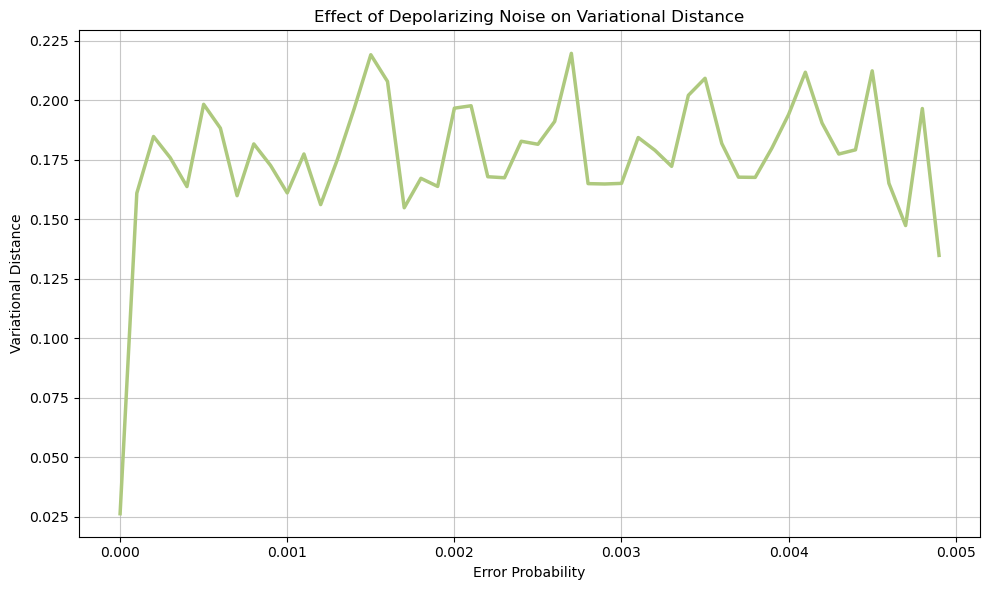

In [ ]:
import math 

p_vals = np.arange(0, 5e-3, 1e-4)
vd_vals = []

for p in p_vals:
    print(p)
    noise_model = create_noise_model(p)

    simulator = AerSimulator(noise_model=noise_model)
    _, vd = run_nonreversible(P, dim, simulator=simulator)
    print(vd)
    vd_vals.append(vd)
    
# Plot results
plt.figure(figsize=(10, 6))
plt.plot(p_vals, vd_vals, color='#aec97e', linewidth=2.5)

plt.title('Effect of Depolarizing Noise on Variational Distance')
plt.xlabel('Error Probability')
plt.ylabel('Variational Distance')
plt.grid(True, alpha=0.7)

plt.tight_layout()
plt.show()

### Effect of Degree on VD - Complexity Classic VS Quantum

In [ ]:
def classic_evolution(degree, P, pi, start_state=0):
    dim = P.shape[0]

    # Initial distribution: concentrated on one state
    end = np.zeros(dim)
    end[start_state] = 1.0

    for _ in range(degree):
        end = end @ P

    vd = 0.5 * np.sum(np.abs(end - pi))

    return end, vd

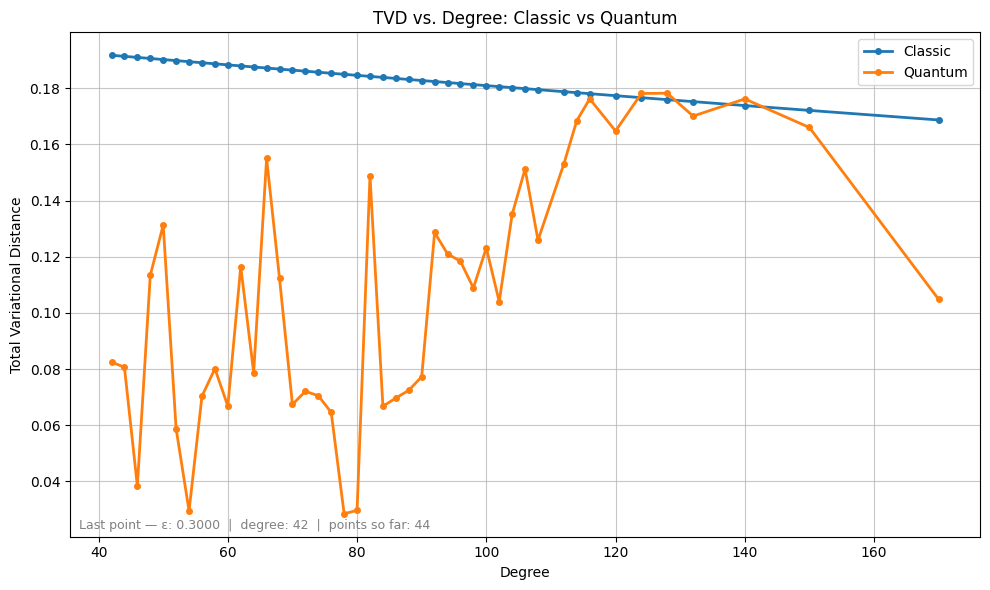

ε=0.3000  degree=42  |  classic TVD=0.191770  quantum TVD=0.082507


In [138]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np

def stationary_distribution(P):
    eigvals, eigvecs = np.linalg.eig(P.T)
    index = np.argmin(np.abs(eigvals - 1))
    pi = np.real(eigvecs[:, index])
    if np.sum(pi) < 0:
        pi = -pi
    pi = pi / np.sum(pi)
    pi = np.maximum(pi, 0.0)
    pi = pi / np.sum(pi)
    return pi

dim = 8
P = np.array([
    [0.54989,     0.34993,     0.079984,    0.019996,    0.0000467782, 0.0000554812, 0.0000605858, 0.0000371548],
    [0.04999,     0.59988,     0.29994,     0.04999,     0.0000467782, 0.0000554812, 0.0000605858, 0.0000371548],
    [0.019996,    0.079984,    0.54989,     0.34993,     0.0000467782, 0.0000554812, 0.0000605858, 0.0000371548],
    [0.29994,     0.04999,     0.04999,     0.59988,     0.0000467782, 0.0000554812, 0.0000605858, 0.0000371548],
    [0.0001731153,0.0002175774,0.0001991756,0.0002101316,0.4996,      0.09992,     0.34972,     0.04996],
    [0.0001731153,0.0002175774,0.0001991756,0.0002101316,0.29976,     0.4996,      0.04996,     0.14988],
    [0.0001731153,0.0002175774,0.0001991756,0.0002101316,0.04996,     0.34972,     0.4996,      0.09992],
    [0.0001731153,0.0002175774,0.0001991756,0.0002101316,0.09992,     0.04996,     0.29976,     0.54956],
], dtype=float)
P = P / P.sum(axis=1, keepdims=True)
pi = stationary_distribution(P)

# Spectral gap from discriminant matrix D
P_rev = np.zeros((dim, dim))
for i in range(dim):
    for j in range(dim):
        P_rev[i, j] = (pi[j] / pi[i]) * P[j, i]

eye = np.eye(dim)
basis = np.array([row.reshape(-1, 1) for row in eye])
swap = sum(np.kron(basis[x], basis[y]) @ np.kron(basis[y].T, basis[x].T)
           for x in range(dim) for y in range(dim))
square = sum(np.sqrt(P[x, y]) * np.kron(basis[x], basis[y]) @ basis[x].T
             for x in range(dim) for y in range(dim))
square_rev = sum(np.sqrt(P_rev[x, y]) * np.kron(basis[x], basis[y]) @ basis[x].T
                 for x in range(dim) for y in range(dim))
D = square_rev.T @ swap @ square
_, svalues, _ = np.linalg.svd(D)
spectral_gap = 1 - svalues[1]

def epsilon_to_degree(epsilon, spectral_gap):
    d_raw = np.arccosh(1 / epsilon) / np.arccosh(1 / (1 - spectral_gap))
    d = int(np.ceil(d_raw))
    if d % 2 != 0:
        d += 1
    return d

# --- Live plot function ---
def plot_live(deg_list, vd_classic_list, vd_quantum_list, current_eps, current_deg):
    fig, ax = plt.subplots(figsize=(10, 6))
    if len(deg_list) > 0:
        ax.plot(deg_list, vd_classic_list, marker="o", markersize=4, label="Classic", linewidth=2)
        ax.plot(deg_list, vd_quantum_list,  marker="o", markersize=4, label="Quantum",  linewidth=2)
    ax.set_title("TVD vs. Degree: Classic vs Quantum")
    ax.set_xlabel("Degree")
    ax.set_ylabel("Total Variational Distance")
    ax.grid(True, which="both", alpha=0.7)
    ax.legend(loc="best")
    ax.text(
        0.01, 0.01,
        f"Last point — ε: {current_eps:.4f}  |  degree: {current_deg}  |  points so far: {len(deg_list)}",
        transform=ax.transAxes,
        fontsize=9,
        color="gray",
        va="bottom"
    )
    plt.tight_layout()
    plt.show()

# --- Sweep ---
epsilon_vals = np.linspace(0.001, 0.3, 200)

deg_plot        = []
vd_vals_classic = []
vd_vals_quantum = []
seen_degrees    = set()

for eps in epsilon_vals:
    d = epsilon_to_degree(eps, spectral_gap)

    if d in seen_degrees:
        continue
    seen_degrees.add(d)

    _, vd_classic = classic_evolution(d, P, pi)
    _, vd_quantum = run_nonreversible(P, dim, epsilon=eps, degree=d)

    deg_plot.append(d)
    vd_vals_classic.append(vd_classic)
    vd_vals_quantum.append(vd_quantum)

    clear_output(wait=True)
    plot_live(deg_plot, vd_vals_classic, vd_vals_quantum, eps, d)
    print(f"ε={eps:.4f}  degree={d}  |  classic TVD={vd_classic:.6f}  quantum TVD={vd_quantum:.6f}")

In [139]:
# Reconstruct the epsilon associated with each stored degree
degree_to_eps = {}

for eps in epsilon_vals:
    d = epsilon_to_degree(eps, spectral_gap)
    if d not in degree_to_eps:
        degree_to_eps[d] = eps

# Find the 3 lowest quantum TVDs
quantum_array = np.array(vd_vals_quantum)
top3_indices = np.argsort(quantum_array)[:3]

print("Top 3 lowest quantum TVDs\n")
print(
    f"{'Rank':<6} {'Epsilon':<12} {'Quantum TVD':<16} "
    f"{'Quantum degree':<18} {'Classical TVD':<18} "
    f"{'Classical degree (to match quantum TVD)'}"
)
print("-" * 110)

for rank, idx in enumerate(top3_indices, 1):
    q_tvd = vd_vals_quantum[idx]
    q_deg = deg_plot[idx]
    eps_val = degree_to_eps[q_deg]
    c_tvd = vd_vals_classic[idx]

    # Find the smallest classical degree that achieves
    # a TVD no larger than the quantum TVD
    match_deg = None
    for d_search in range(2, 10000, 2):
        _, vd_c = classic_evolution(d_search, P, pi)
        if vd_c <= q_tvd:
            match_deg = d_search
            break

    print(
        f"{rank:<6} "
        f"{eps_val:<12.6f} "
        f"{q_tvd:<16.6f} "
        f"{q_deg:<18} "
        f"{c_tvd:<18.6f} "
        f"{match_deg if match_deg is not None else '>10000'}"
    )

Top 3 lowest quantum TVDs

Rank   Epsilon      Quantum TVD      Quantum degree     Classical TVD      Classical degree (to match quantum TVD)
--------------------------------------------------------------------------------------------------------------
1      0.061101     0.028447         78                 0.184986           1950
2      0.178296     0.029483         54                 0.189481           1914
3      0.056593     0.029688         80                 0.184616           1908


In [ ]:
# Find the 3 lowest quantum TVDs
quantum_array = np.array(vd_vals_quantum)
top3_indices = np.argsort(quantum_array)[:3]

print("Top 3 lowest quantum TVDs\n")
print(f"{'Rank':<6} {'Quantum TVD':<16} {'Quantum degree':<18} {'Classical TVD':<18} {'Classical degree (to match quantum TVD)'}")
print("-" * 85)

for rank, idx in enumerate(top3_indices, 1):
    q_tvd    = vd_vals_quantum[idx]
    q_deg    = deg_plot[idx]
    c_tvd    = vd_vals_classic[idx]  # classical TVD at the same degree

    # Find the smallest classical degree that brings classical TVD <= q_tvd
    match_deg = None
    for d_search in range(2, 10000, 2):
        _, vd_c = classic_evolution(d_search, P, pi)
        if vd_c <= q_tvd:
            match_deg = d_search
            break

    print(f"{rank:<6} {q_tvd:<16.6f} {q_deg:<18} {c_tvd:<18.6f} {match_deg if match_deg is not None else '>10000'}")

Top 3 lowest quantum TVDs

Rank   Quantum TVD      Quantum degree     Classical TVD      Classical degree (to match quantum TVD)
-------------------------------------------------------------------------------------
1      0.039573         80                 0.184616           1620
2      0.040923         54                 0.189481           1586
3      0.041977         46                 0.191004           1562


### Effect of Epsilon on VD

0.01
0.015358104313446353
0.02
0.01225491847707115
0.03
0.009120329021778104
0.04
0.007297376985515244
0.05
0.016701214017682386
0.06
0.011811160938624062
0.07
0.012228884972075634
0.08
0.01664069197645289
0.09
0.019699041982797427
0.1
0.019246540250549806
0.11
0.018538368781872205
0.12
0.022755996763197495
0.13
0.018920737713800928
0.14
0.025434559362429447
0.15
0.02407529383649301
0.16
0.023418496921660023
0.17
0.025694714010465275
0.18
0.027981448250620253
0.19
0.030965613300176952
0.2
0.036037028990651296
0.21
0.035135651771485824
0.22
0.036459455074486904
0.23
0.037216971755183195
0.24
0.04338934808490516
0.25
0.03794325939056478
0.26
0.04086299956418742
0.27
0.04183222334676272
0.28
0.04212412510403508
0.29
0.04130009976979787


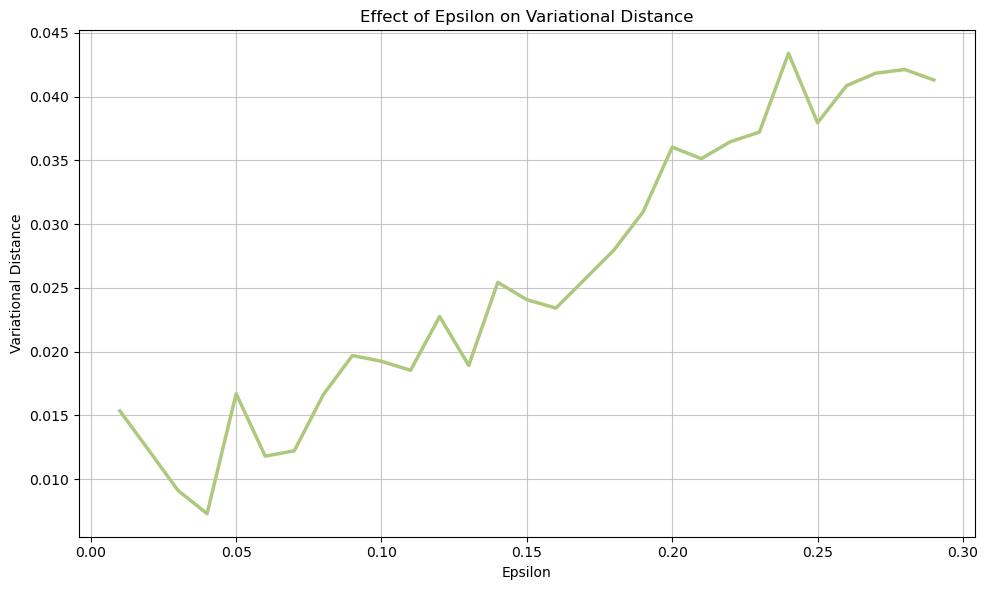

In [ ]:
epsilon_vals = np.arange(1e-2, 3e-1, 1e-2)
vd_vals = []

for epsilon in epsilon_vals:
    print(epsilon)
    _, vd = run_nonreversible(P, dim, epsilon=epsilon)
    print(vd)
    vd_vals.append(vd)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(epsilon_vals, vd_vals, color='#aec97e',linewidth=2.5)

plt.title('Effect of Epsilon on Variational Distance')
plt.xlabel('Epsilon')
plt.ylabel('Variational Distance')
plt.grid(True, alpha=0.7)

plt.tight_layout()
plt.show()